In [1]:
import os
import shutil

for path in [
    "/content/Project_GNN",
    "/content/generated_crops_fewshot",
]:
    if os.path.exists(path):
        shutil.rmtree(path)

print("Cleaned.")

Cleaned.


In [ ]:
clone repo và cài thư viện

In [3]:
!git clone https://github.com/2274802010922/Project_GNN.git /content/Project_GNN
%cd /content/Project_GNN
!pip install -q -r requirements.txt

Cloning into '/content/Project_GNN'...
remote: Enumerating objects: 367, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 367 (delta 36), reused 15 (delta 15), pack-reused 288 (from 2)
Receiving objects: 100% (367/367), 1.20 MiB | 4.00 MiB/s, done.
Resolving deltas: 100% (169/169), done.
/content/Project_GNN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.4 MB/s eta 0:00:00


kiểm tra loader trước khi train

In [4]:
from dataset import download_dataset, load_image_paths_and_labels

dataset_path = download_dataset()
image_paths, labels, class_names, source = load_image_paths_and_labels(dataset_path)

print("SOURCE:", source)
print("NUM SAMPLES:", len(image_paths))
print("NUM CLASSES:", len(class_names))
print("FIRST 10 CLASSES:", class_names[:10])
print("FIRST 5 PATHS:", image_paths[:5])

100%|██████████| 240M/240M [00:01<00:00, 193MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/anhduy091100/vaipe-minimal-dataset/versions/1
Crop output directory: /content/generated_crops_fewshot
Label source: vaipe_json_boxes
Total cropped instances: 312
Total classes after filtering (>= 2 samples/class): 59
Top classes by sample count:
  Hoat-Huyet-Duong-Nao: 34
  Tatanol-500mg-VBP: 28
  Amoxicillin-500mg: 26
  Partamol-500mg: 20
  Alpha-Chymotrypsine: 13
  Droxicef-500mg: 13
  Flagyl-250mg: 10
  Panadol-500mg: 9
  Colchicin-1mg: 8
  Cephalexin-500mg: 7
  Enalapril-5mg: 7
  Acetaminophen: 7
  Amlodipine-5mg: 5
  Vitamin-3B: 5
  Piracetam-800mg: 5
  Clorpheniramin-4mg: 5
  Halixol: 4
  Acetylcysteine: 4
  Loratadine-10mg: 4
  LIVOLIN-FORTE: 4
SOURCE: vaipe_json_boxes
NUM SAMPLES: 312
NUM CLASSES: 59
FIRST 10 CLASSES: ['Acetaminophen', 'Acetylcysteine', 'Agifuros-40mg', 'Agilodin-10mg', 'Allopurinol-STELLA-300mg', 'Alpha-Chymotrypsine', 'Amlodipine-5mg', 'Amoxicillin-500mg', 'Atorvastatin-10mg', 'Boganic-Forte-Vien-Nang']
F

In [5]:
with open("/content/Project_GNN/main.py", "r", encoding="utf-8") as f:
    text = f.read()

print("FewShotGNN" in text)
print("train_fewshot_model" in text)
print(text[:500])

True
True
import os

import torch

from dataset import download_dataset, inspect_dataset_structure, load_image_paths_and_labels
from explain import run_gnn_explainer
from feature_extractor import extract_features
from gnn_model import FewShotGNN
from graph_builder import build_full_graph
from interactive_graph import visualize_interactive_graph
from train import prepare_fewshot_splits, train_fewshot_model
from visualize import (
    plot_class_distribution,
    plot_degree_distribution,
    plot_similarit


chạy pipeline

In [6]:
!python /content/Project_GNN/main.py


===== STEP 1: DOWNLOAD DATASET =====
Using Colab cache for faster access to the 'vaipe-minimal-dataset' dataset.
Dataset downloaded to: /kaggle/input/vaipe-minimal-dataset

===== STEP 2: LOAD IMAGE PATHS + LABELS =====
Crop output directory: /content/generated_crops_fewshot
Label source: vaipe_json_boxes
Total cropped instances: 312
Total classes after filtering (>= 2 samples/class): 59
Top classes by sample count:
  Hoat-Huyet-Duong-Nao: 34
  Tatanol-500mg-VBP: 28
  Amoxicillin-500mg: 26
  Partamol-500mg: 20
  Alpha-Chymotrypsine: 13
  Droxicef-500mg: 13
  Flagyl-250mg: 10
  Panadol-500mg: 9
  Colchicin-1mg: 8
  Cephalexin-500mg: 7
  Enalapril-5mg: 7
  Acetaminophen: 7
  Amlodipine-5mg: 5
  Vitamin-3B: 5
  Piracetam-800mg: 5
  Clorpheniramin-4mg: 5
  Halixol: 4
  Acetylcysteine: 4
  Loratadine-10mg: 4
  LIVOLIN-FORTE: 4

===== STEP 3: EXTRACT FEATURES =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd

In [8]:
import os
out_dir = "/content/Project_GNN/outputs"
print(sorted(os.listdir(out_dir)) if os.path.exists(out_dir) else "No outputs folder")

['class_distribution.png', 'confusion_matrix.png', 'degree_distribution.png', 'explainer_edge_importance.png', 'explanation_subgraph.png', 'fewshot_gnn.pt', 'graph_with_images.png', 'interactive_graph.html', 'resnet18_features.npy', 'similarity_distribution.png', 'training_curves.png', 'tsne_embeddings.png']



--- class_distribution.png ---


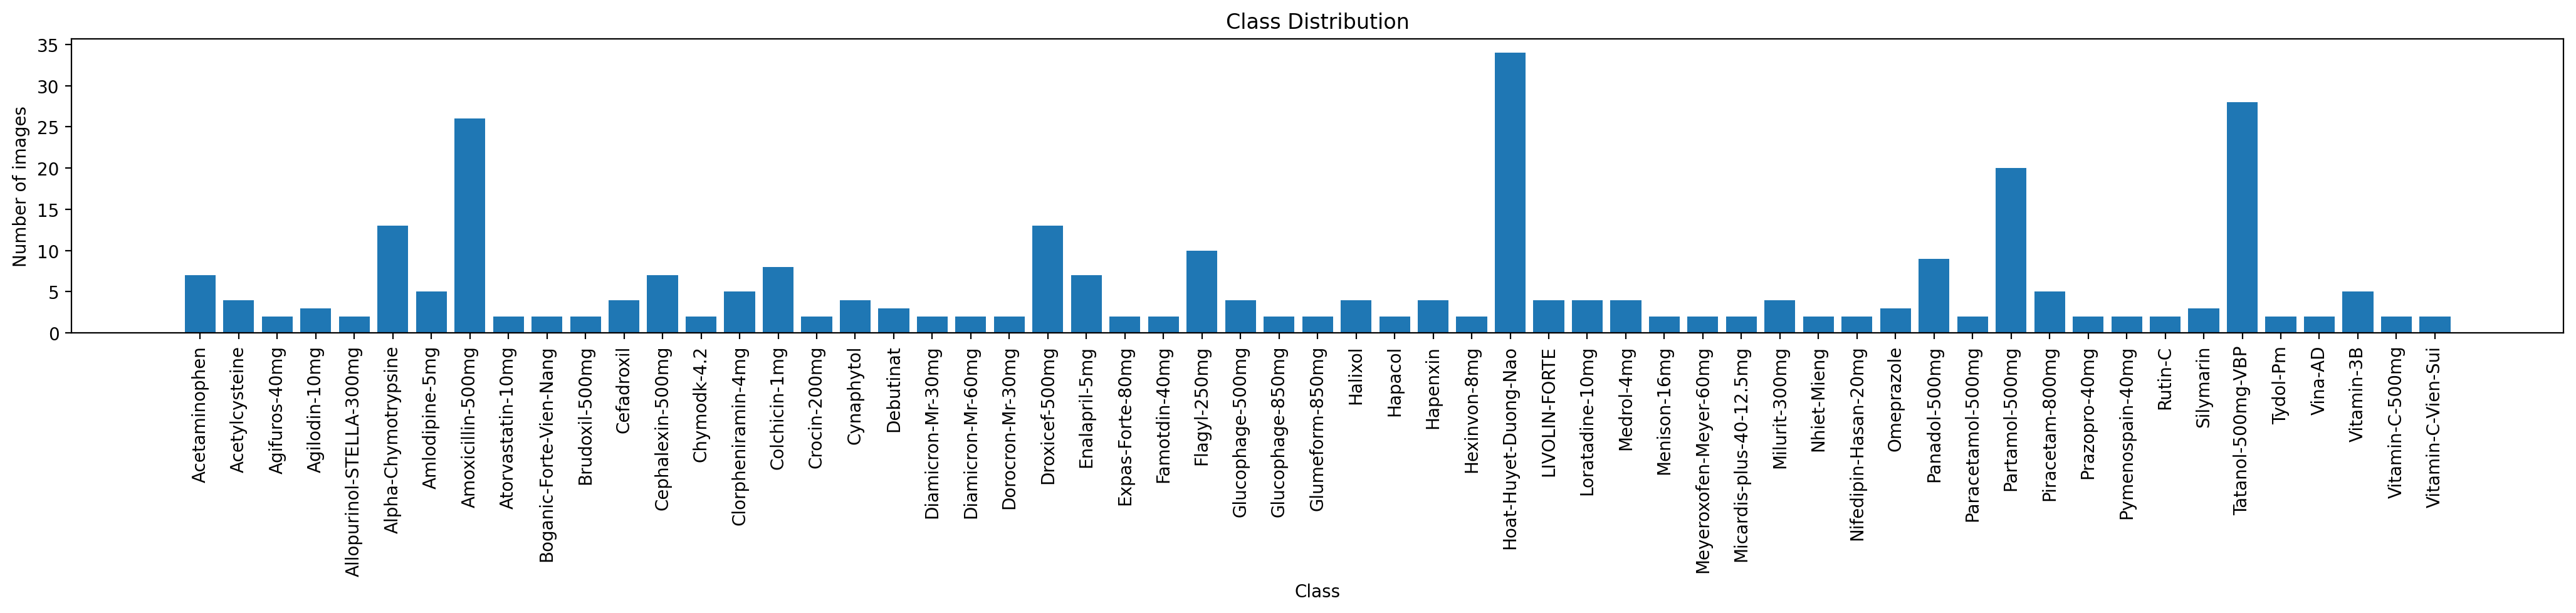


--- degree_distribution.png ---


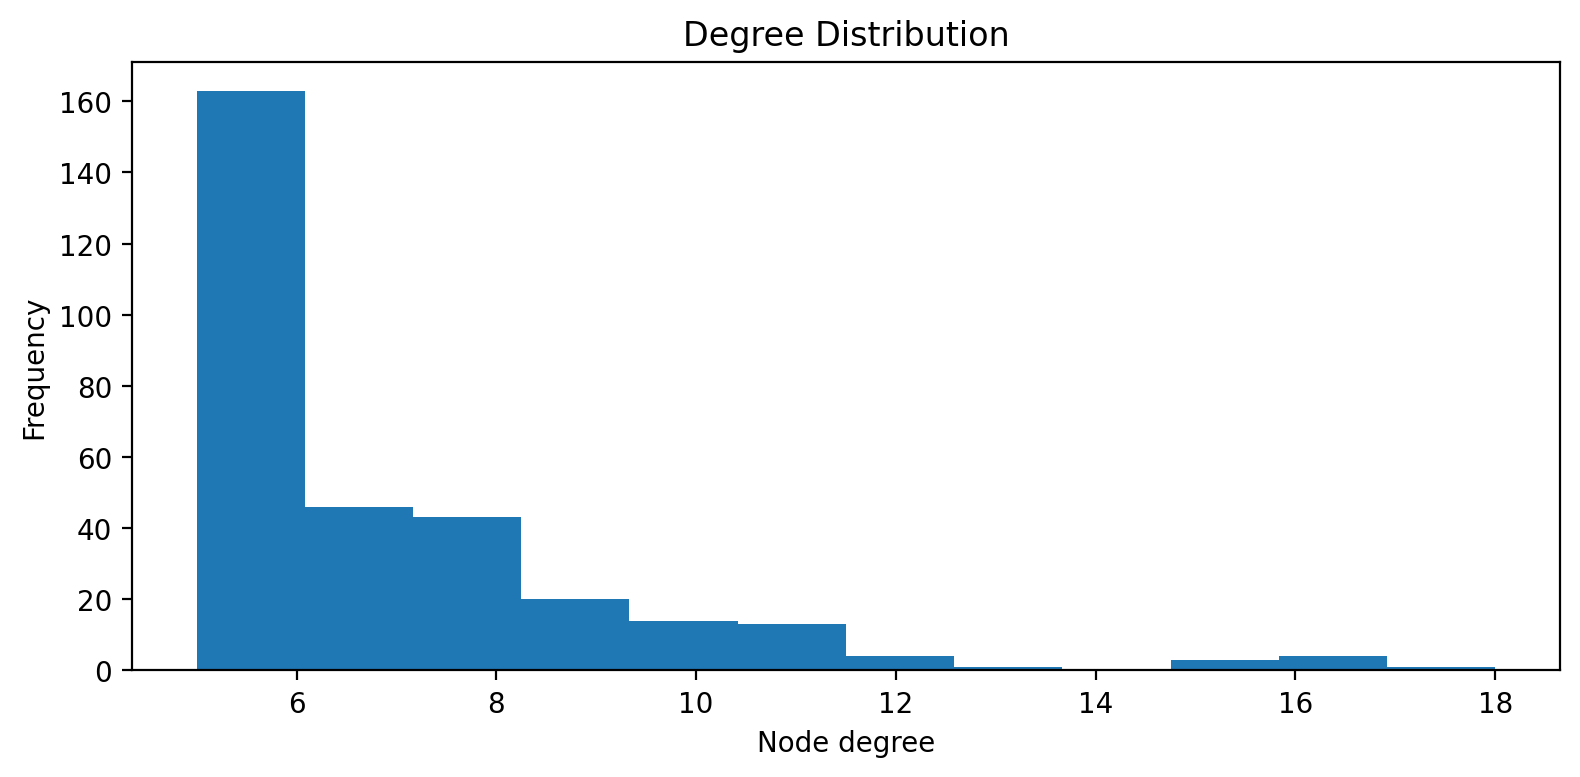


--- similarity_distribution.png ---


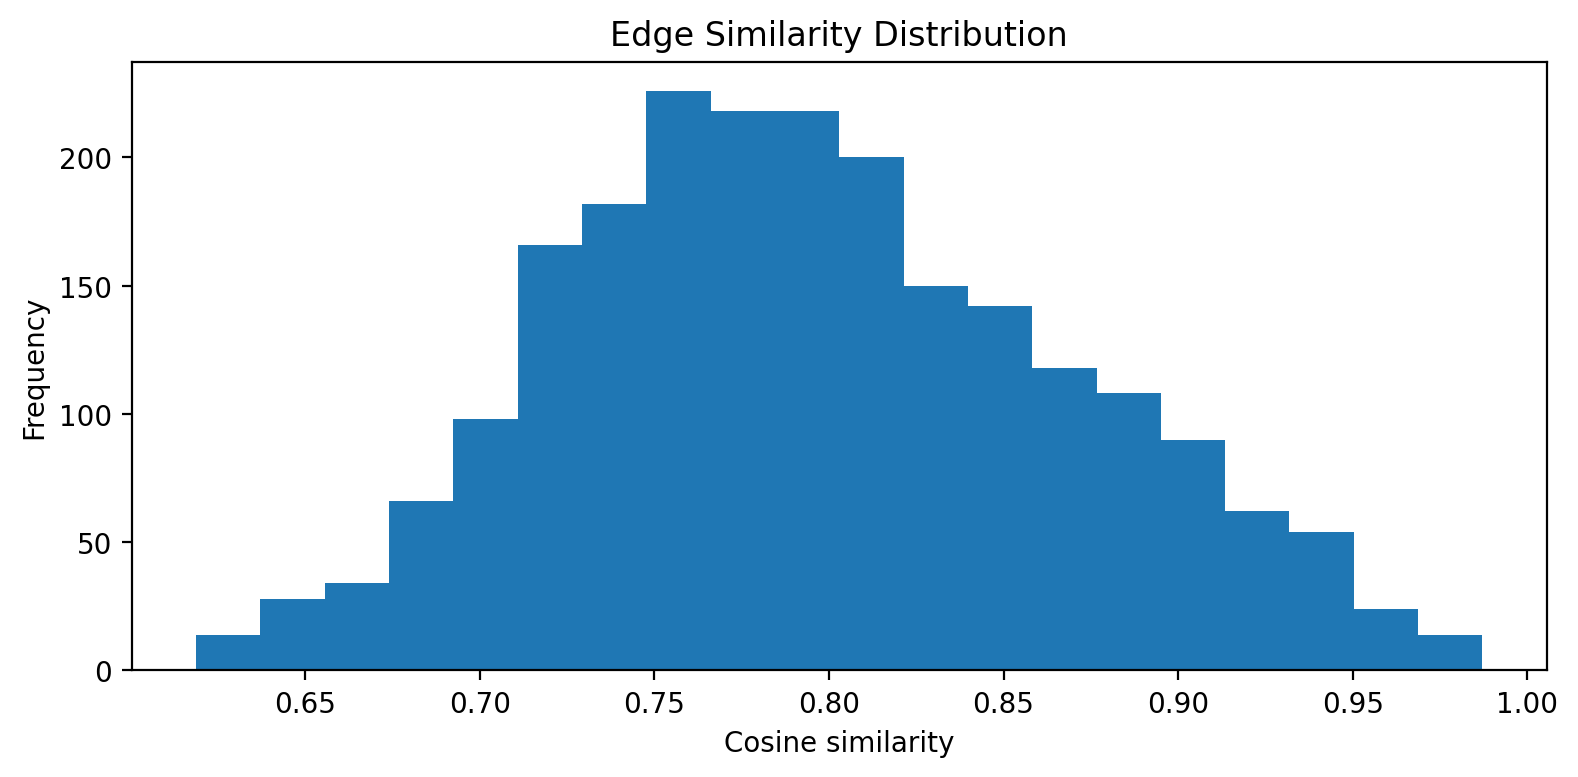


--- training_curves.png ---


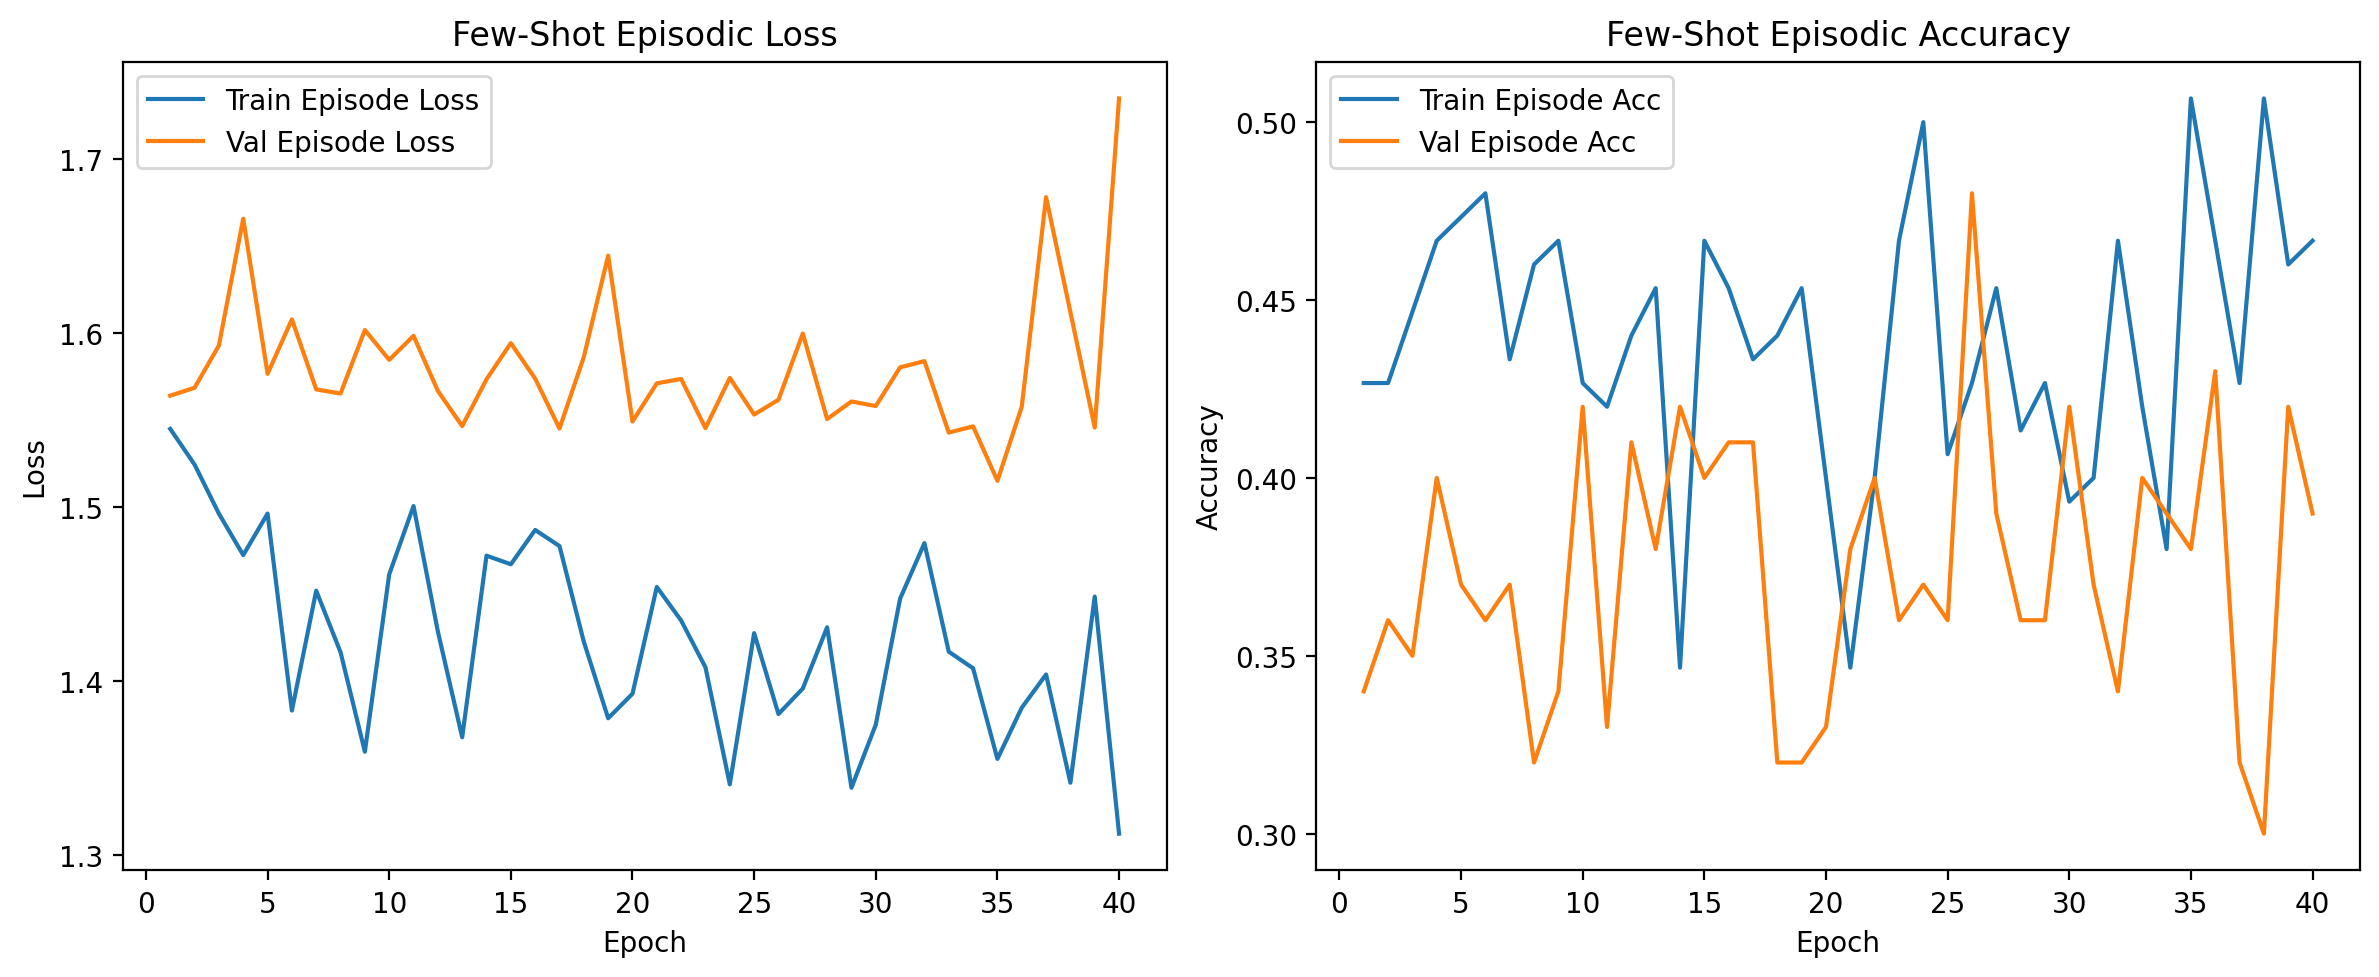


--- confusion_matrix.png ---


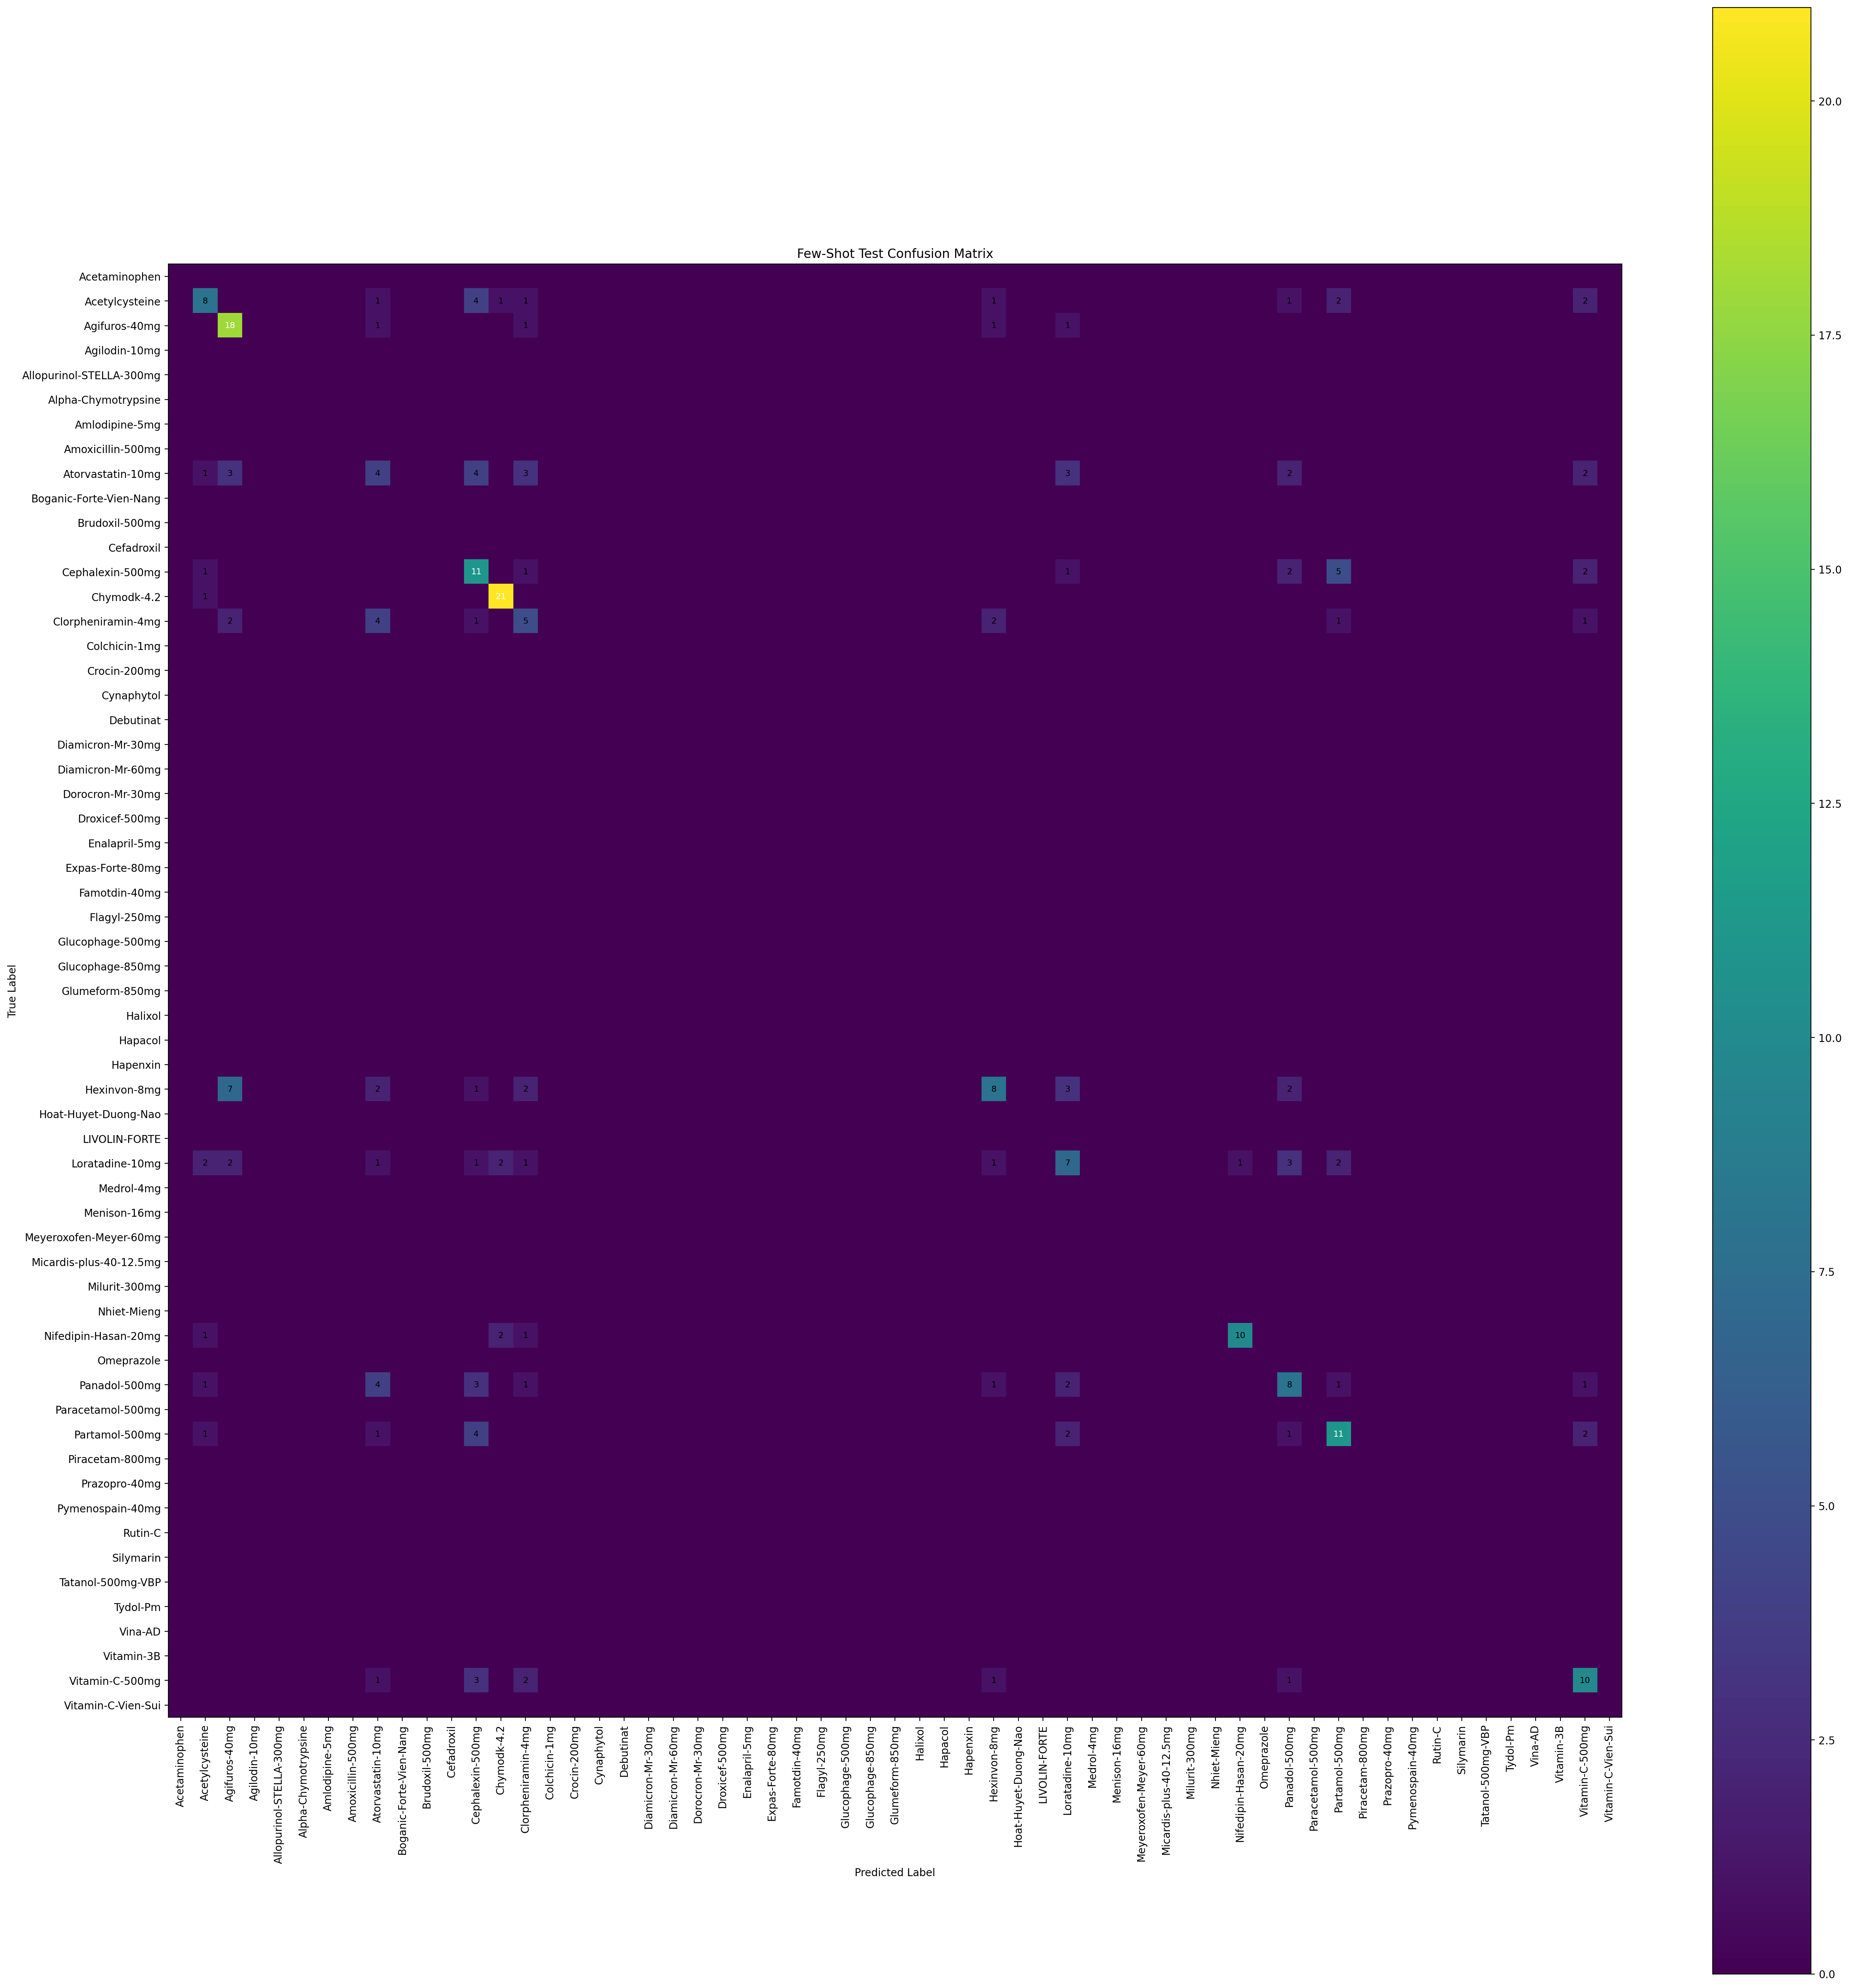


--- tsne_embeddings.png ---


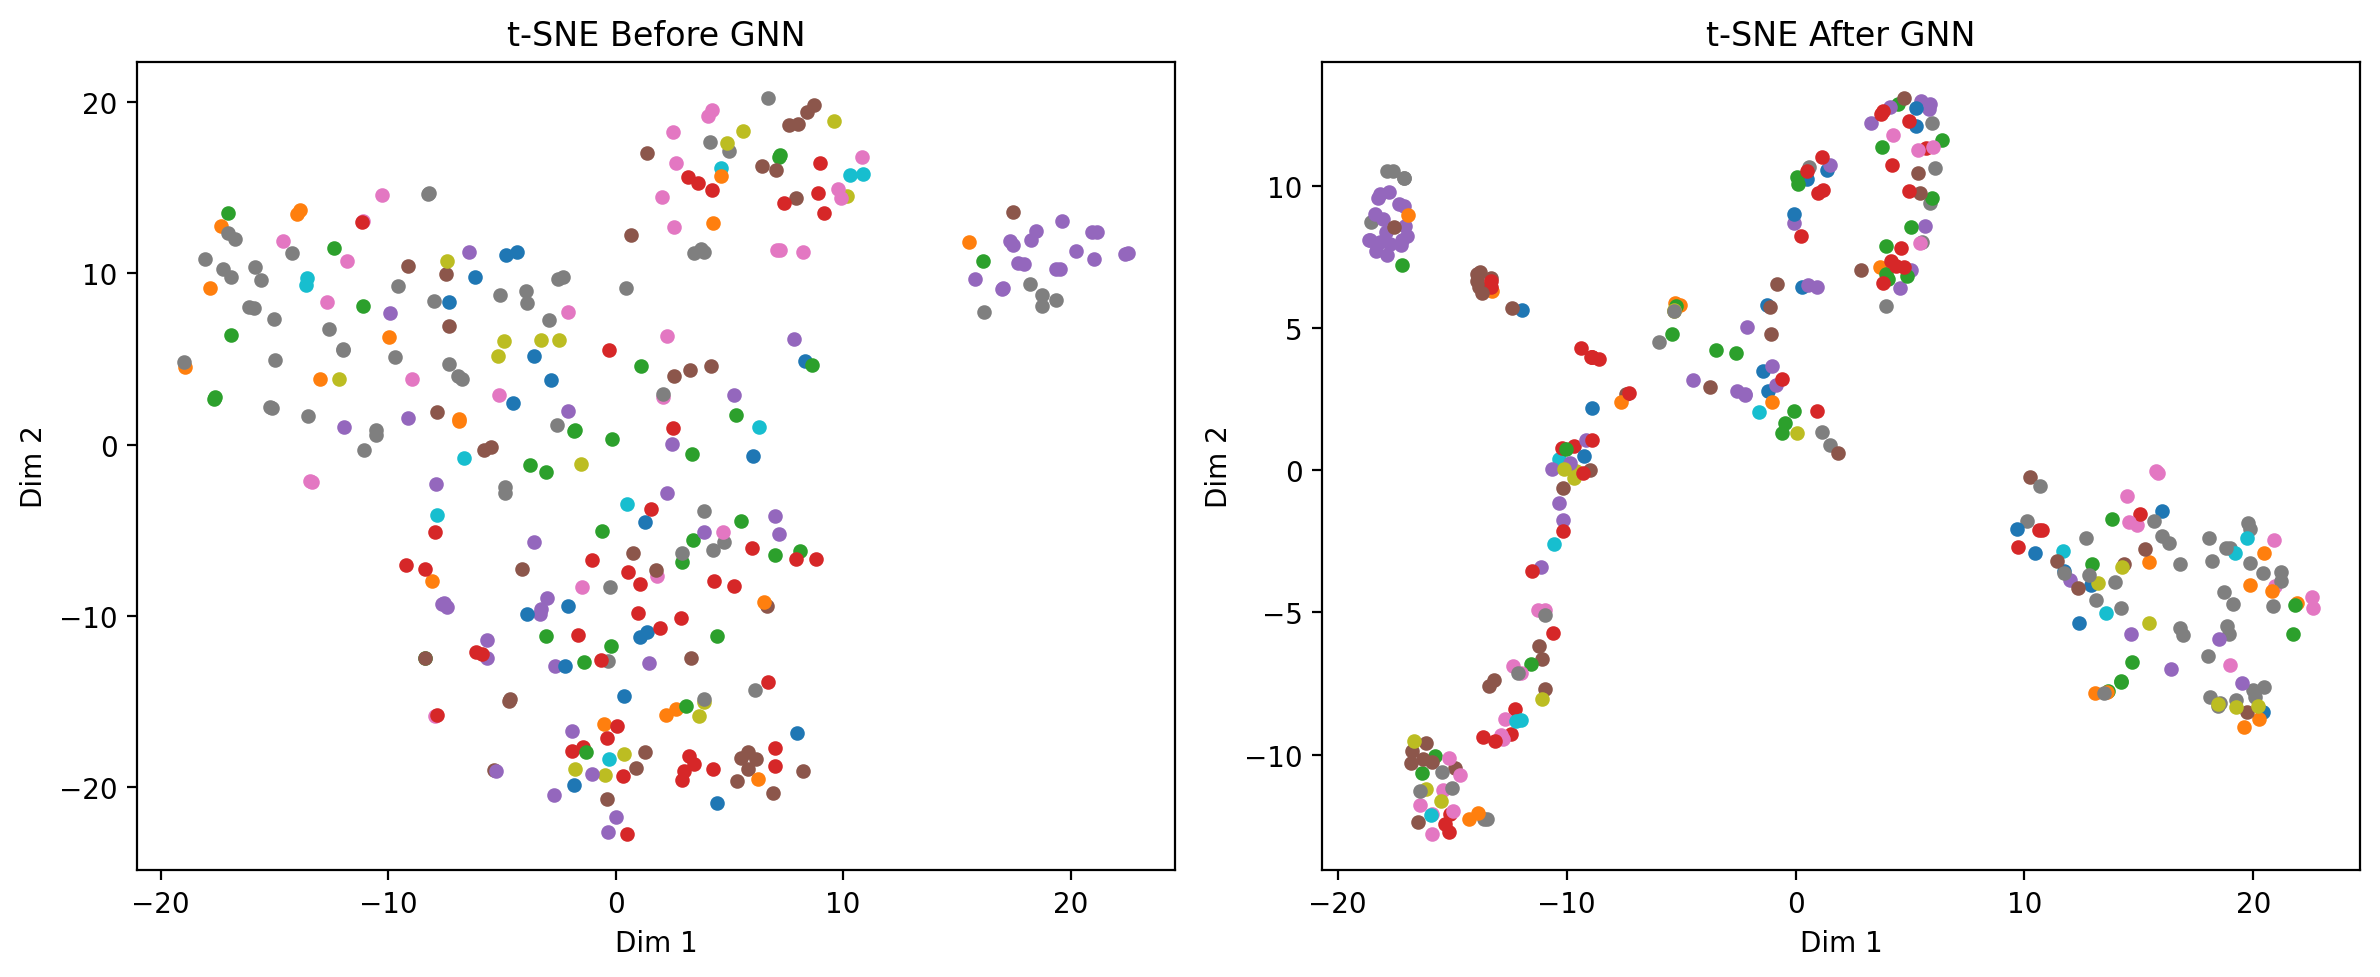


--- graph_with_images.png ---


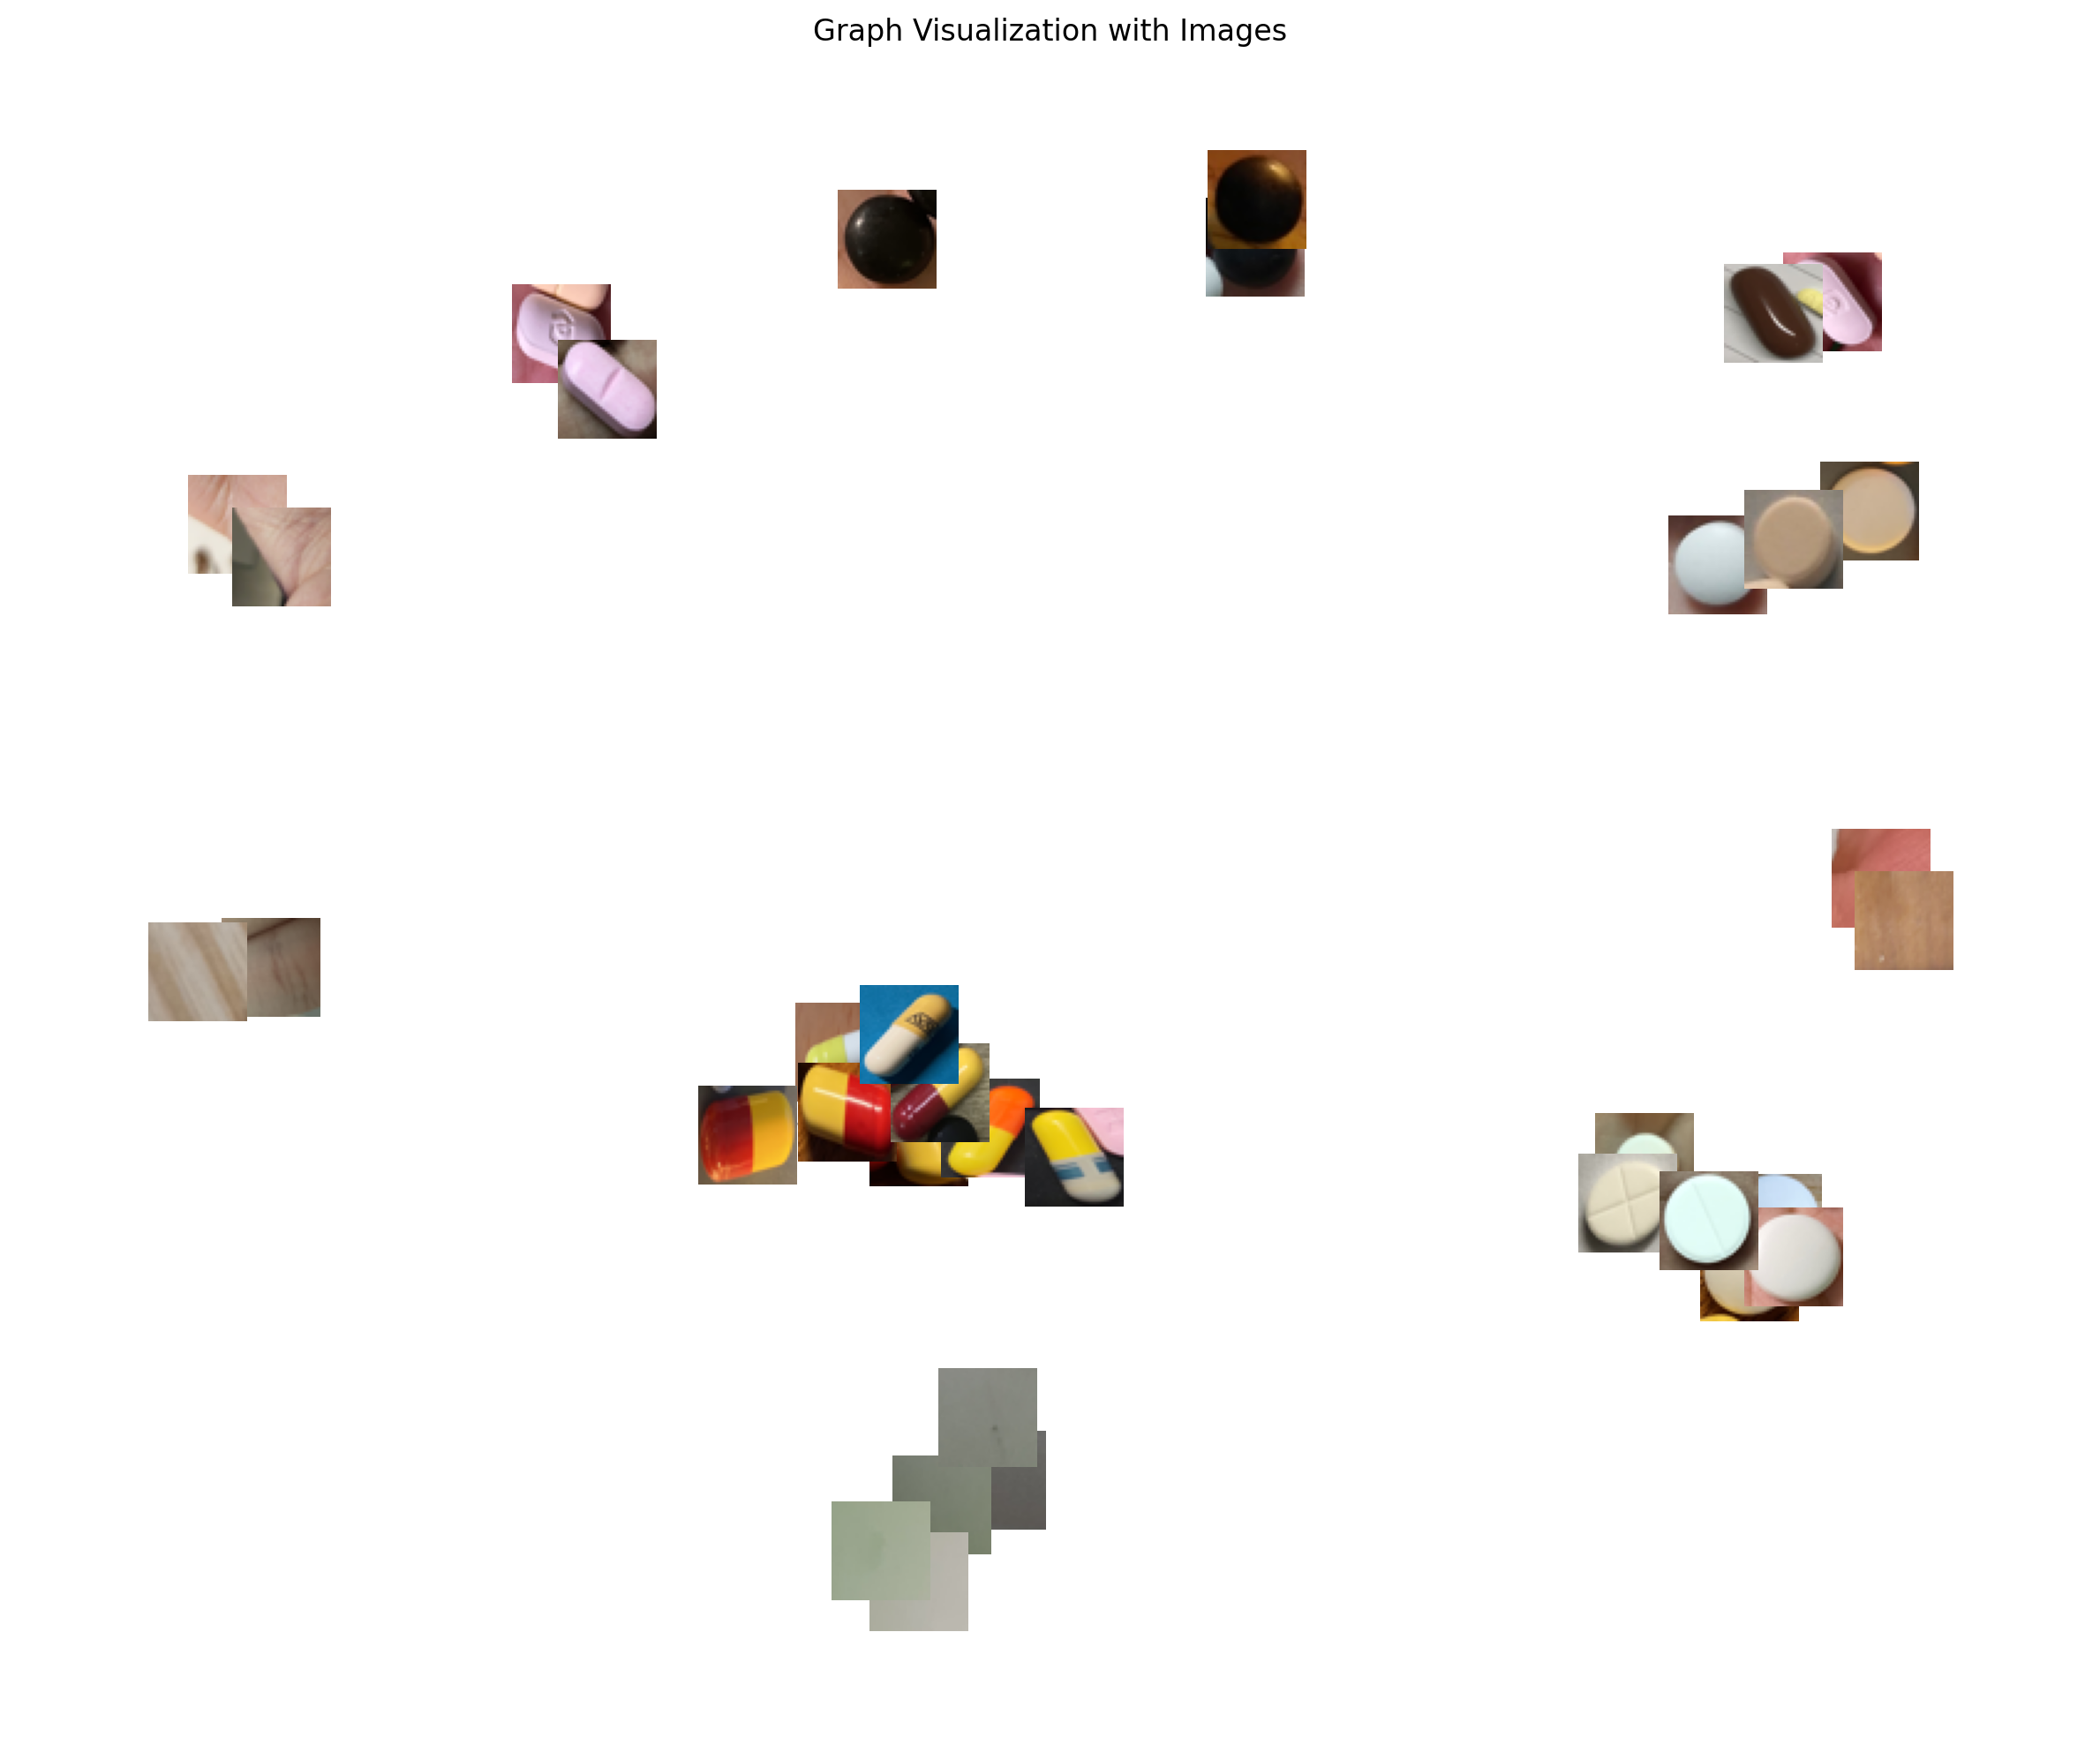


--- explainer_edge_importance.png ---


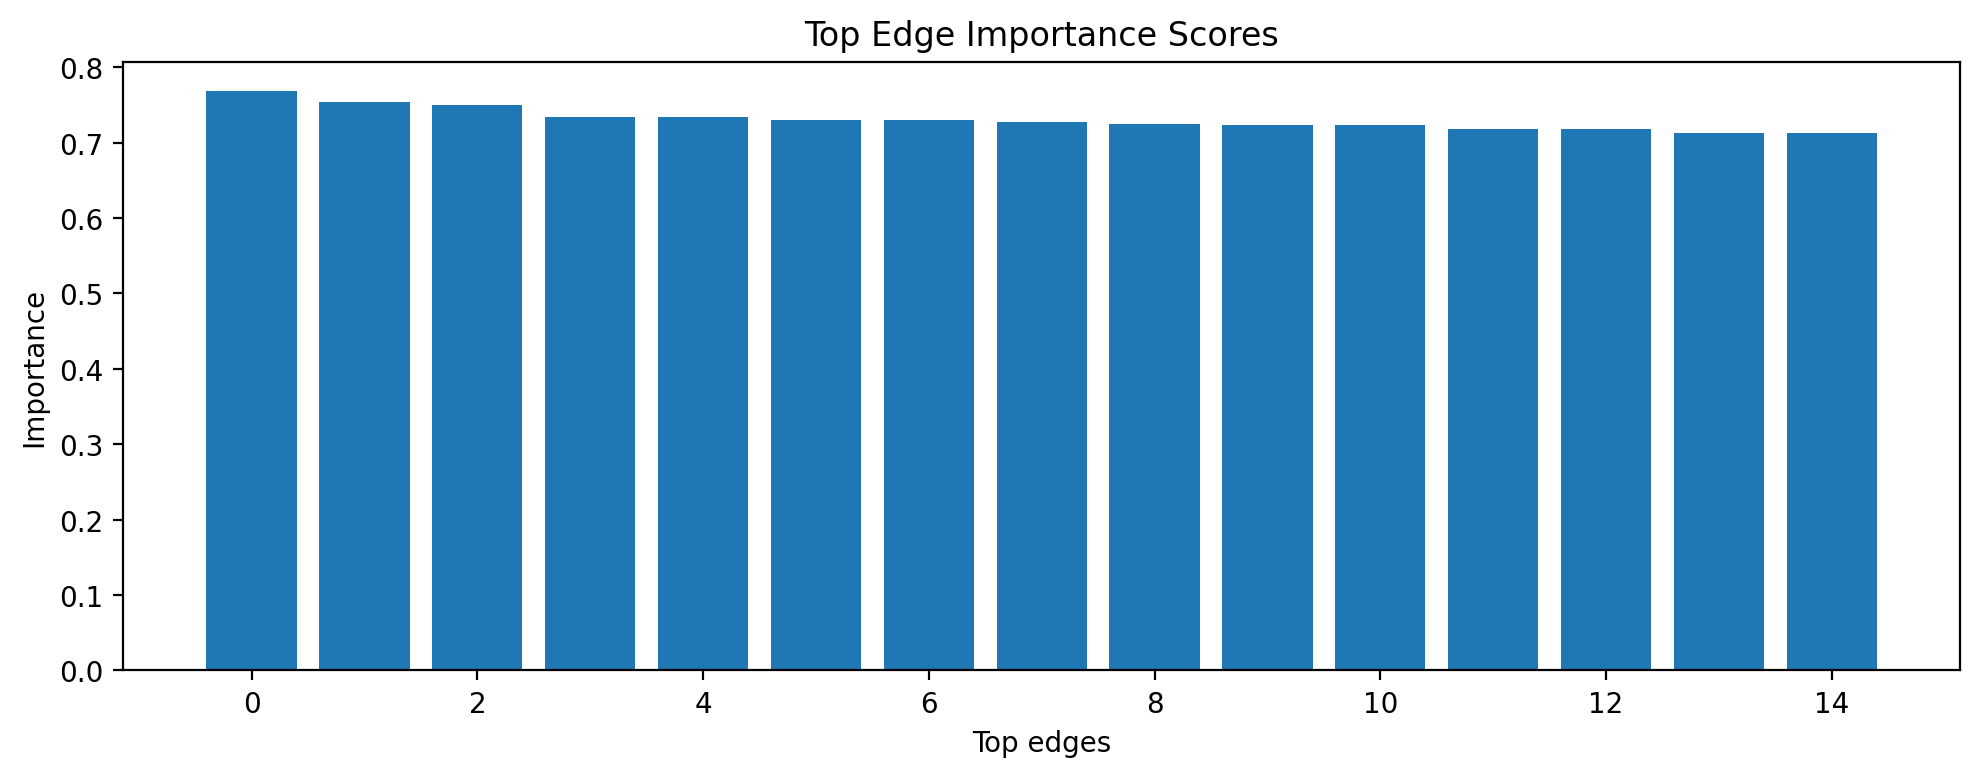


--- explanation_subgraph.png ---


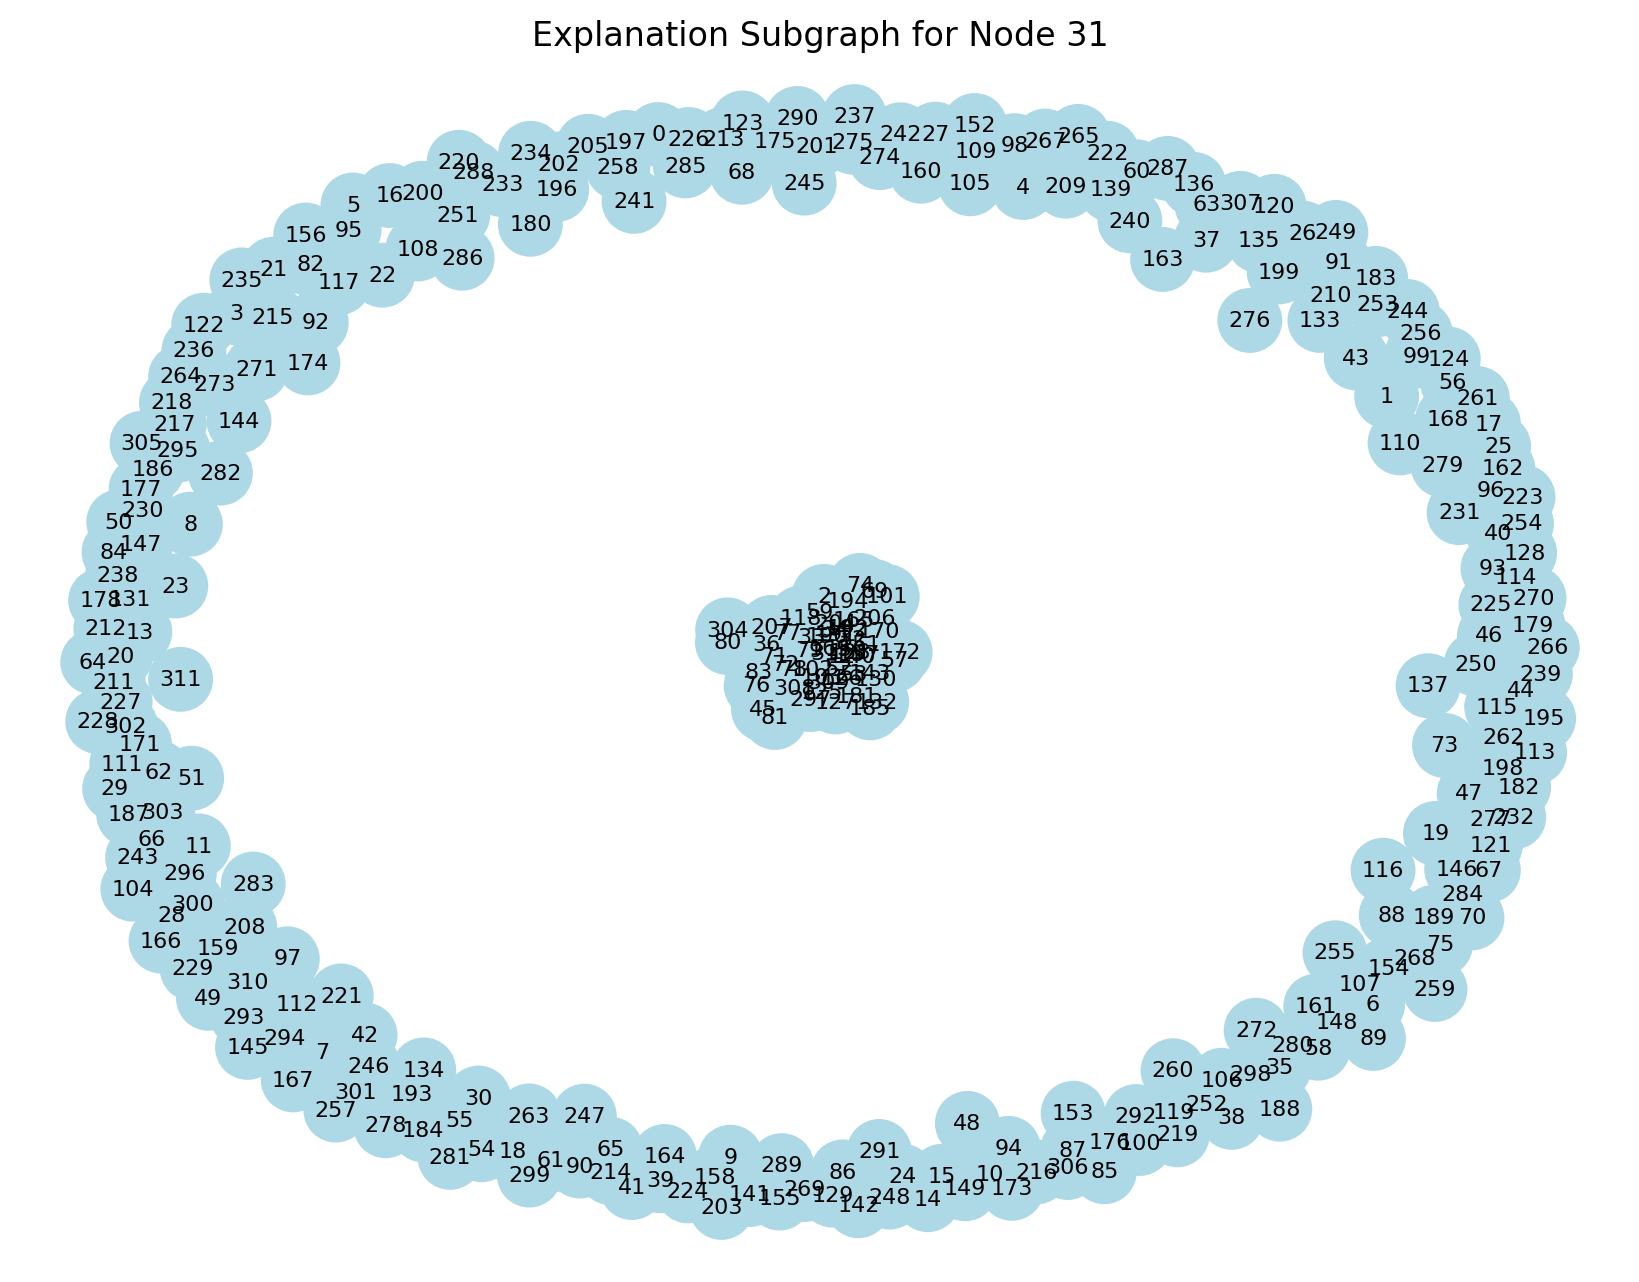

In [7]:
from IPython.display import Image, display
import os

files_to_show = [
    "class_distribution.png",
    "degree_distribution.png",
    "similarity_distribution.png",
    "training_curves.png",
    "confusion_matrix.png",
    "tsne_embeddings.png",
    "graph_with_images.png",
    "explainer_edge_importance.png",
    "explanation_subgraph.png",
]

for f in files_to_show:
    p = f"/content/Project_GNN/outputs/{f}"
    if os.path.exists(p):
        print(f"\n--- {f} ---")
        display(Image(filename=p))